In [ ]:
import os
import re
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from IPython.display import display
import matplotlib.patches as mpatches

In [ ]:
# --- KONFIGURASI PATH ---
base_path = '/content/drive/MyDrive/parameters'
protocols = ['tcp', 'quic']
scenarios = ['5to5', '5to24', '24to5', '24to24']
bandwidths = ['10mbps', '100mbps', '500mbps', '1000mbps']

# Urutan visualisasi bandwidth
bw_order = {'10mbps': 10, '100mbps': 100, '500mbps': 500, '1000mbps': 1000}

In [ ]:
# --- REGEX PATTERNS ---
ping_sum_loss = re.compile(r'([\d\.]+)% packet loss')
ping_sum_lat = re.compile(r'rtt min/avg/max/mdev\s*=\s*[\d\.]+/([\d\.]+)/')
ping_line_lat = re.compile(r'time=([\d\.]+) ms')
ping_line_seq = re.compile(r'icmp_seq=(\d+)')

iperf_summary = re.compile(r'0\.0000-\d+\.\d+\s+sec\s+[\d\.]+\s+[KMG]?Bytes\s+([\d\.]+)\s+([KMG]?bits/sec)')
iperf_interval = re.compile(r'sec\s+([\d\.]+)\s+([KMG]?Bytes)\s+([\d\.]+)\s+([KMG]?bits/sec)')
iperf_time_interval = re.compile(r'-(\d+\.\d+)\s+sec')

buff_text_pat = re.compile(r'Total buffering time\s*:\s*([\d\.]+)')

In [ ]:
# --- HELPER FUNCTIONS ---
def normalize_mbps(val, unit):
    if unit == 'Gbits/sec': return val * 1000.0
    if unit == 'Mbits/sec': return val
    if unit == 'Kbits/sec': return val / 1000.0
    if unit == 'bits/sec': return val / 1000000.0
    return 0.0

def normalize_bytes_to_mb(val, unit):
    if unit == 'GBytes': return val * 1024.0
    if unit == 'MBytes': return val
    if unit == 'KBytes': return val / 1024.0
    if unit == 'Bytes': return val / 1048576.0
    return 0.0

# --- PARSING FUNCTIONS ---
def parse_ping(file_path):
    try:
        with open(file_path, 'r') as f:
            content = f.read()
            loss_match = ping_sum_loss.search(content)
            lat_match = ping_sum_lat.search(content)
            if loss_match and lat_match:
                return float(loss_match.group(1)), float(lat_match.group(1))
            else:
                lats = [float(x) for x in ping_line_lat.findall(content)]
                avg_lat = np.mean(lats) if lats else 0
                seqs = [int(x) for x in ping_line_seq.findall(content)]
                expected = 120
                max_seq = max(seqs) if seqs else 0
                total_sent = max(expected, max_seq)
                received = len(seqs)
                loss = ((total_sent - received) / total_sent) * 100.0 if total_sent > 0 else 100.0
                return loss, avg_lat
    except:
        return None, None

def parse_iperf(file_path):
    try:
        with open(file_path, 'r') as f:
            content = f.read()
            summary_match = iperf_summary.search(content)
            if summary_match:
                val = float(summary_match.group(1))
                unit = summary_match.group(2)
                return normalize_mbps(val, unit)
            lines = content.split('\n')
            total_transfer_mb = 0
            max_time = 0
            for line in lines:
                match = iperf_interval.search(line)
                time_match = iperf_time_interval.search(line)
                if match:
                    trans_val = float(match.group(1))
                    trans_unit = match.group(2)
                    total_transfer_mb += normalize_bytes_to_mb(trans_val, trans_unit)
                if time_match:
                    t = float(time_match.group(1))
                    if t > max_time: max_time = t
            if max_time > 0:
                return (total_transfer_mb * 8) / max_time
            else:
                return 0
    except:
        return 0

def parse_buffering(file_path):
    try:
        with open(file_path, 'r') as f:
            content = f.read().strip()
            match = buff_text_pat.search(content)
            if match:
                return float(match.group(1))
            try:
                return float(content)
            except:
                return 0
    except:
        return 0

In [ ]:
# --- MAIN ENGINE ---
data_rows = []
print("Sedang memproses data... Mohon tunggu.")

for proto in protocols:
    for scen in scenarios:
        for bw in bandwidths:
            base_dir = os.path.join(base_path, proto, scen, bw)

            # PING
            files = glob.glob(os.path.join(base_dir, 'ping', '*.log'))
            for f in files:
                loss, lat = parse_ping(f)
                if loss is not None:
                    data_rows.append({'Protocol': proto.upper(), 'Scenario': scen, 'BW': bw, 'Metric': 'Packet Loss (%)', 'Value': loss, 'Order': bw_order[bw]})
                    data_rows.append({'Protocol': proto.upper(), 'Scenario': scen, 'BW': bw, 'Metric': 'Latency (ms)', 'Value': lat, 'Order': bw_order[bw]})

            # IPERF
            files = glob.glob(os.path.join(base_dir, 'iperf', '*.log'))
            for f in files:
                tput = parse_iperf(f)
                data_rows.append({'Protocol': proto.upper(), 'Scenario': scen, 'BW': bw, 'Metric': 'Throughput (Mbps)', 'Value': tput, 'Order': bw_order[bw]})

            # BUFFERING
            path_buff = os.path.join(base_dir, 'buffering')
            if os.path.exists(os.path.join(path_buff, 'counts')):
                 path_buff = os.path.join(path_buff, 'counts')
            files = glob.glob(os.path.join(path_buff, '*buffer*.log'))
            for f in files:
                b_time = parse_buffering(f)
                data_rows.append({'Protocol': proto.upper(), 'Scenario': scen, 'BW': bw, 'Metric': 'Buffer Time (s)', 'Value': b_time, 'Order': bw_order[bw]})

df = pd.DataFrame(data_rows)
print(f"Selesai! {len(df)} data berhasil diproses.")

Sedang memproses data... Mohon tunggu.
Selesai! 3929 data berhasil diproses.


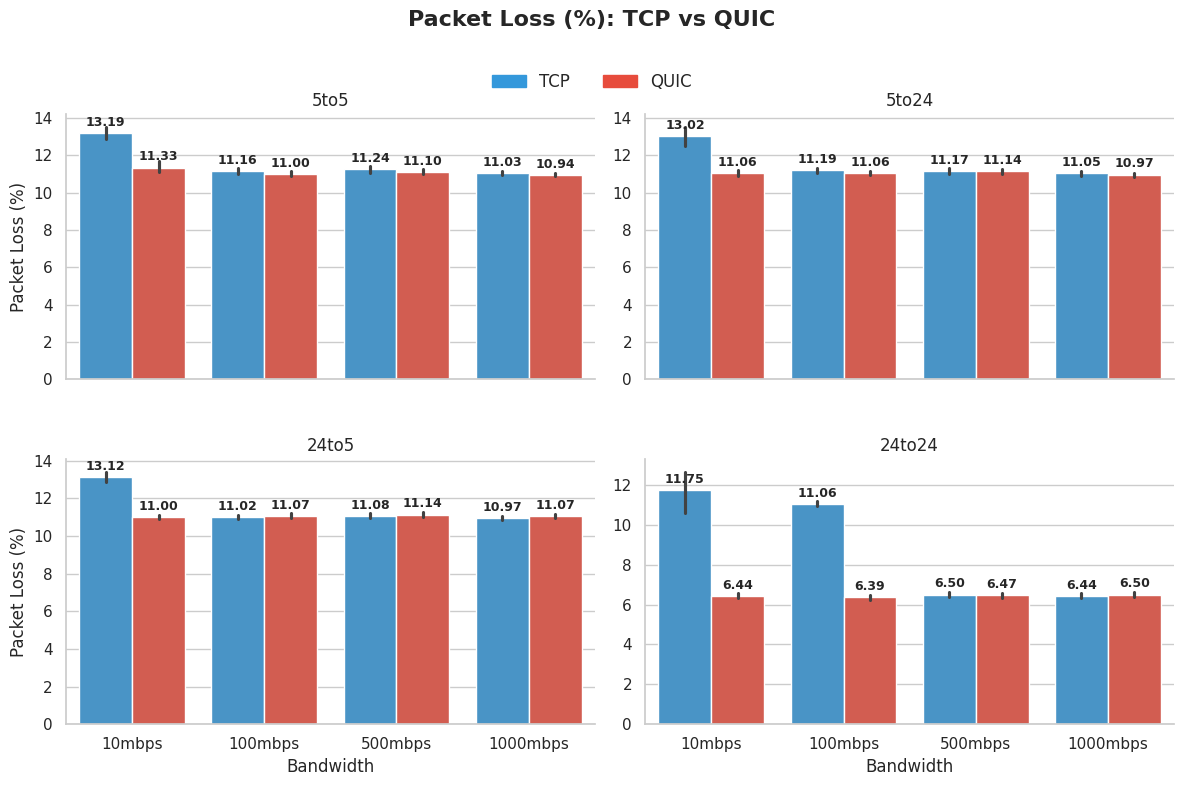

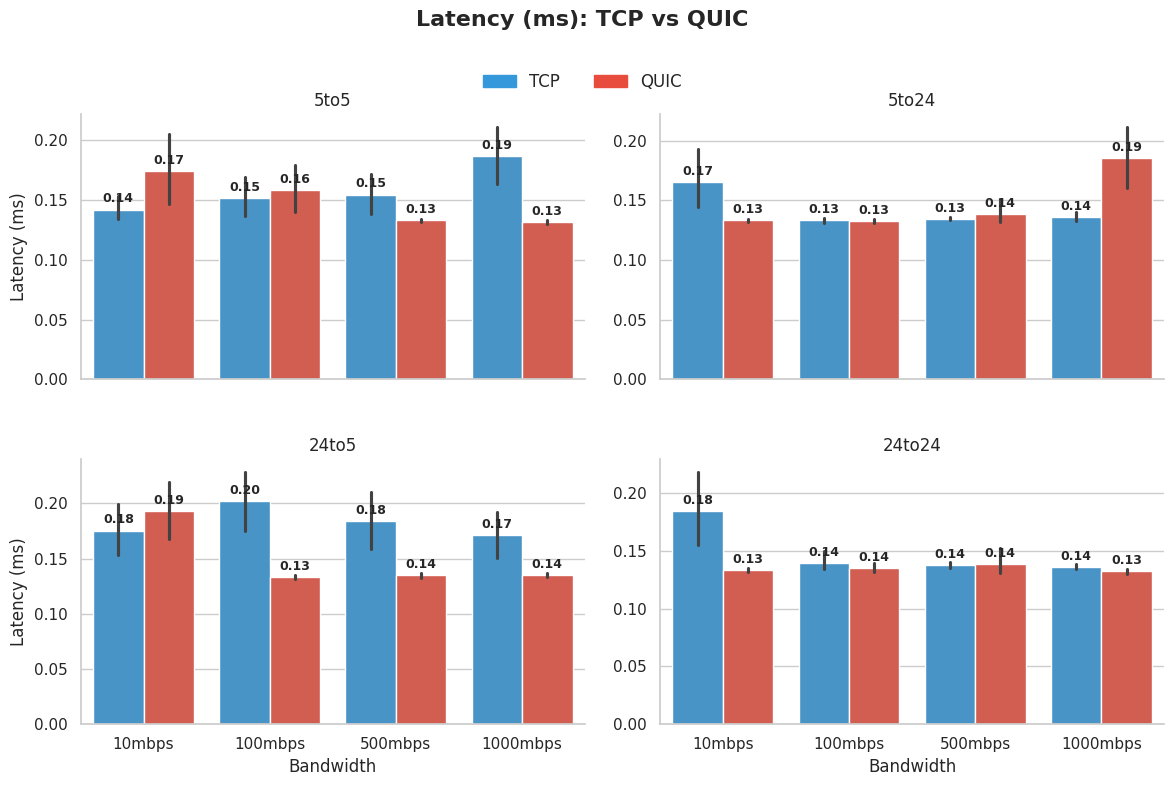

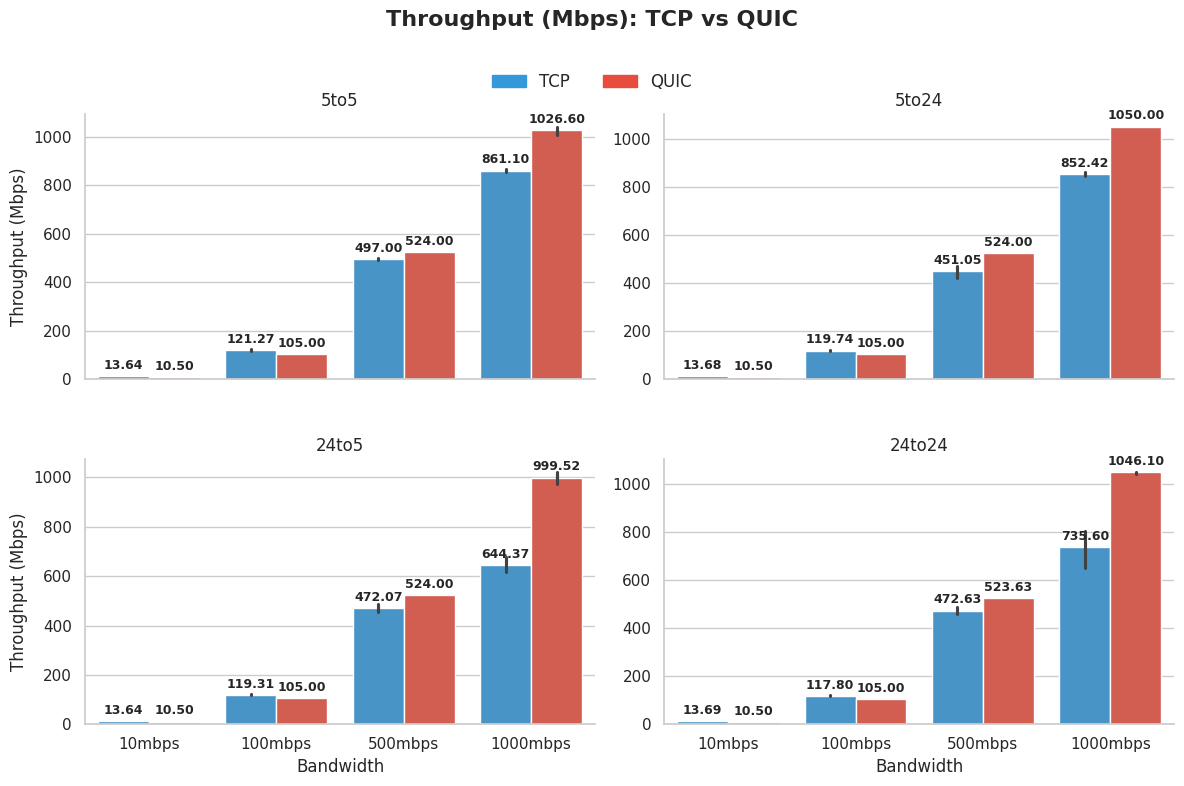

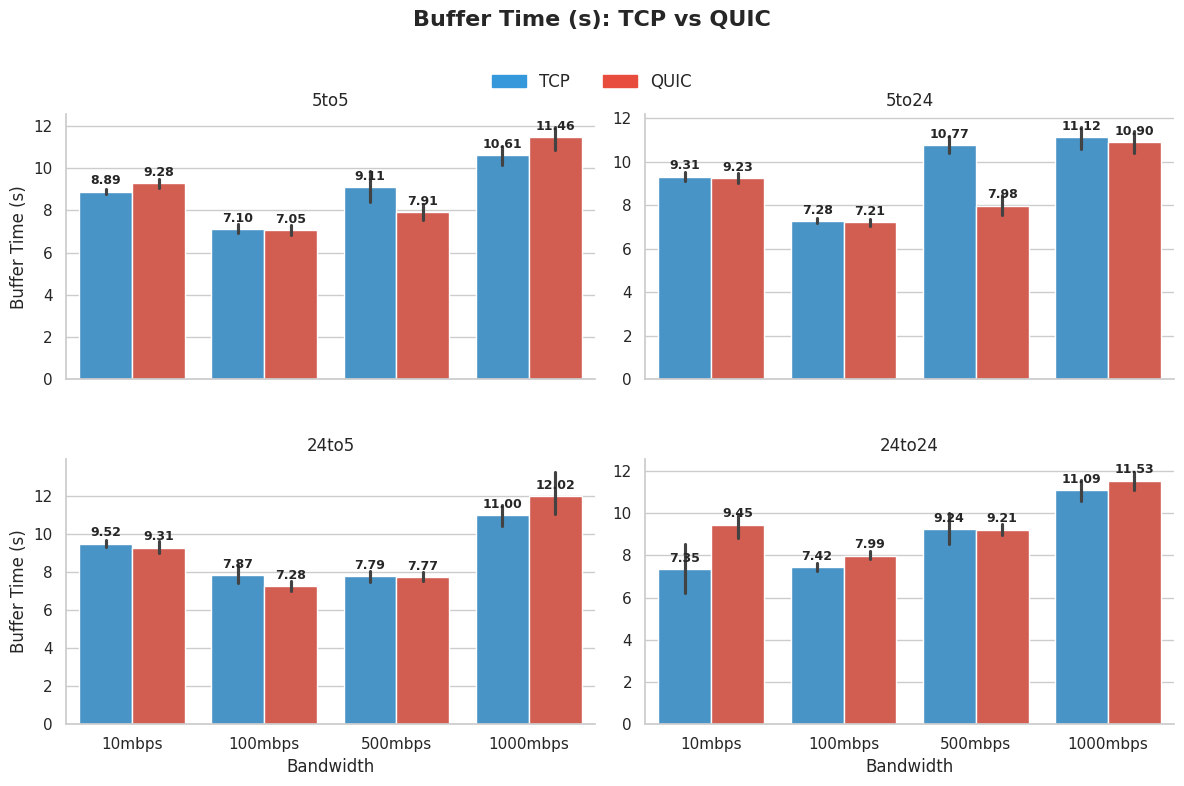

In [ ]:
import matplotlib.patches as mpatches # Penting untuk membuat legend manual

# --- VISUALISASI FINAL (DENGAN LEGEND MANUAL) ---
sns.set_theme(style="whitegrid")
metrics = ['Packet Loss (%)', 'Latency (ms)', 'Throughput (Mbps)', 'Buffer Time (s)']
palette = {"QUIC": "#e74c3c", "TCP": "#3498db"} # Merah & Biru

for metric in metrics:
    df_subset = df[df['Metric'] == metric]

    if df_subset.empty:
        print(f"Data untuk {metric} tidak ditemukan atau kosong.")
        continue

    # 1. Plot Grafik (Matikan legend bawaan agar tidak merusak layout)
    g = sns.catplot(
        data=df_subset,
        x='BW',
        y='Value',
        hue='Protocol',
        col='Scenario',
        col_wrap=2,
        kind='bar',
        palette=palette,
        height=4,
        aspect=1.5,
        sharey=False,
        legend=False,  # Tetap False, kita buat sendiri di bawah
        order=['10mbps', '100mbps', '500mbps', '1000mbps']
    )

    # 2. Atur Label Sumbu & Judul Subplot
    g.set_axis_labels("Bandwidth", metric)
    g.set_titles("{col_name}")

    # 3. Label Angka di Atas Batang
    for ax in g.axes.flat:
        for container in ax.containers:
            ax.bar_label(container, fmt='%.2f', padding=3, fontsize=9, fontweight='bold')

    # --- BAGIAN PENTING: MEMBUAT LEGEND MANUAL ---
    # Karena kita tahu warnanya, kita "paksa" python menggambar kotak warna tersebut
    tcp_patch = mpatches.Patch(color=palette["TCP"], label='TCP')
    quic_patch = mpatches.Patch(color=palette["QUIC"], label='QUIC')

    # Menempatkan Legend di Tengah Atas
    g.fig.legend(handles=[tcp_patch, quic_patch],
                 loc='upper center',
                 bbox_to_anchor=(0.5, 0.92), # Posisi (X=Tengah, Y=Agak turun dari judul)
                 ncol=2,
                 fontsize=12,
                 frameon=False) # Tanpa kotak garis pinggir agar bersih

    # 4. Judul Besar
    g.fig.suptitle(f'{metric}: TCP vs QUIC', fontsize=16, fontweight='bold', y=0.98)

    # 5. Atur Margin (Memberi ruang kosong di atas untuk Judul & Legend)
    g.fig.subplots_adjust(top=0.85, hspace=0.3)

    plt.show()
    print("\n" + "="*80 + "\n")

==========================================================================================

Mengekstrak data interval per-paket (Latency) untuk Skenario 5to24...


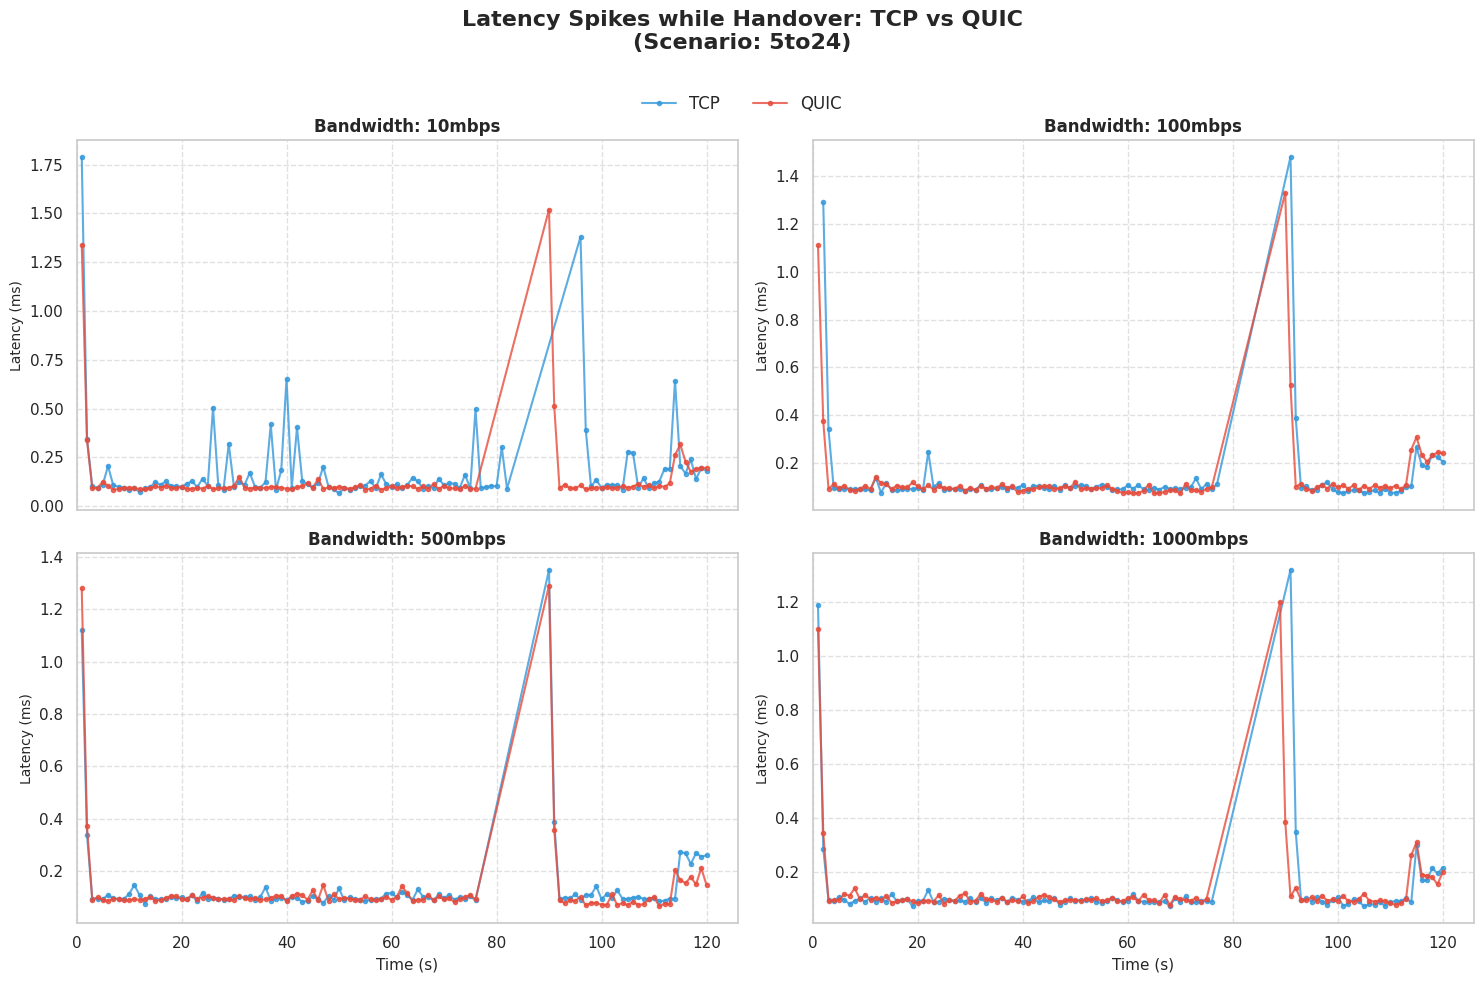


Grafik 4 grid berhasil dibuat!


In [ ]:
import os
import re
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- 1. KONFIGURASI TARGET ---
base_path = '/content/drive/MyDrive/parameters'
protocols = ['tcp', 'quic']
scenario_target = '5to24'
bandwidths = ['10mbps', '100mbps', '500mbps', '1000mbps']

# --- 2. REGEX UNTUK PING ---
# Mencari nomor urut paket (icmp_seq) sebagai penanda waktu/detik dan nilai latency (time=... ms)
ping_line_pat = re.compile(r'icmp_seq=(\d+).*?time=([\d\.]+)\s*ms')

# --- 3. PERSIAPAN FIGURE (2x2 GRID) ---
print(f"Mengekstrak data interval per-paket (Latency) untuk Skenario {scenario_target}...")
fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharex=True)
axes = axes.flatten() # Memudahkan iterasi ke 4 subplot
palette = {"TCP": "#3498db", "QUIC": "#e74c3c"}

# --- 4. EKSTRAKSI DAN PLOTTING DATA ---
for i, bw in enumerate(bandwidths):
    ax = axes[i]
    data_found = False

    for proto in protocols:
        dir_path = os.path.join(base_path, proto, scenario_target, bw, 'ping')
        files = glob.glob(os.path.join(dir_path, '*.log'))

        if files:
            # Ambil file pertama saja sebagai representasi runtun waktu
            file_to_read = files[0]
            seqs = []
            lats = []

            try:
                with open(file_to_read, 'r') as f:
                    for line in f:
                        match = ping_line_pat.search(line)
                        if match:
                            seq = int(match.group(1))     # icmp_seq (dianggap sebagai detik ke-)
                            lat = float(match.group(2))   # Waktu latency dalam ms
                            seqs.append(seq)
                            lats.append(lat)
                            data_found = True
            except Exception as e:
                print(f"Gagal membaca {file_to_read}: {e}")

            if seqs and lats:
                # Mengurutkan berdasarkan sequence untuk menghindari garis mundur
                sorted_indices = np.argsort(seqs)
                seqs = np.array(seqs)[sorted_indices]
                lats = np.array(lats)[sorted_indices]

                ax.plot(seqs, lats,
                        label=f'{proto.upper()}',
                        color=palette[proto.upper()],
                        linewidth=1.5,
                        marker='o', markersize=3, alpha=0.8)

    # Styling tiap subplot
    if data_found:
        ax.set_title(f'Bandwidth: {bw}', fontsize=12, fontweight='bold')
        ax.set_ylabel('Latency (ms)', fontsize=10)
        ax.grid(True, linestyle='--', alpha=0.6)

        # Batasi sumbu X agar mulai dari paket ke-1
        ax.set_xlim(left=0)

        # Legend ax.legend() telah dihapus dari bagian ini
    else:
        ax.set_title(f'{bw} (Data Tidak Ditemukan)')

# Label sumbu X cukup di baris paling bawah
for ax in axes[2:]:
    ax.set_xlabel('Time (s)', fontsize=11)

# Judul Utama Gambar
fig.suptitle(f'Latency Spikes while Handover: TCP vs QUIC\n(Scenario: {scenario_target})',
             fontsize=16, fontweight='bold', y=0.98)

# ==============================================================================
# PERUBAHAN: MENAMBAHKAN LEGEND GABUNGAN DI ATAS TENGAH
# ==============================================================================
handles, labels = axes[0].get_legend_handles_labels()

# Meletakkan legend di tengah atas
fig.legend(handles, labels,
           loc='upper center',
           bbox_to_anchor=(0.5, 0.91),
           ncol=2,
           fontsize=12,
           frameon=False)

plt.tight_layout()
# Menurunkan sedikit posisi grafik untuk memberi ruang ekstra pada Legend
fig.subplots_adjust(top=0.85)
plt.show()
print("\nGrafik 4 grid berhasil dibuat!")

Membuat 4 Grid Grafik Time-Series Throughput untuk Skenario 24to5...


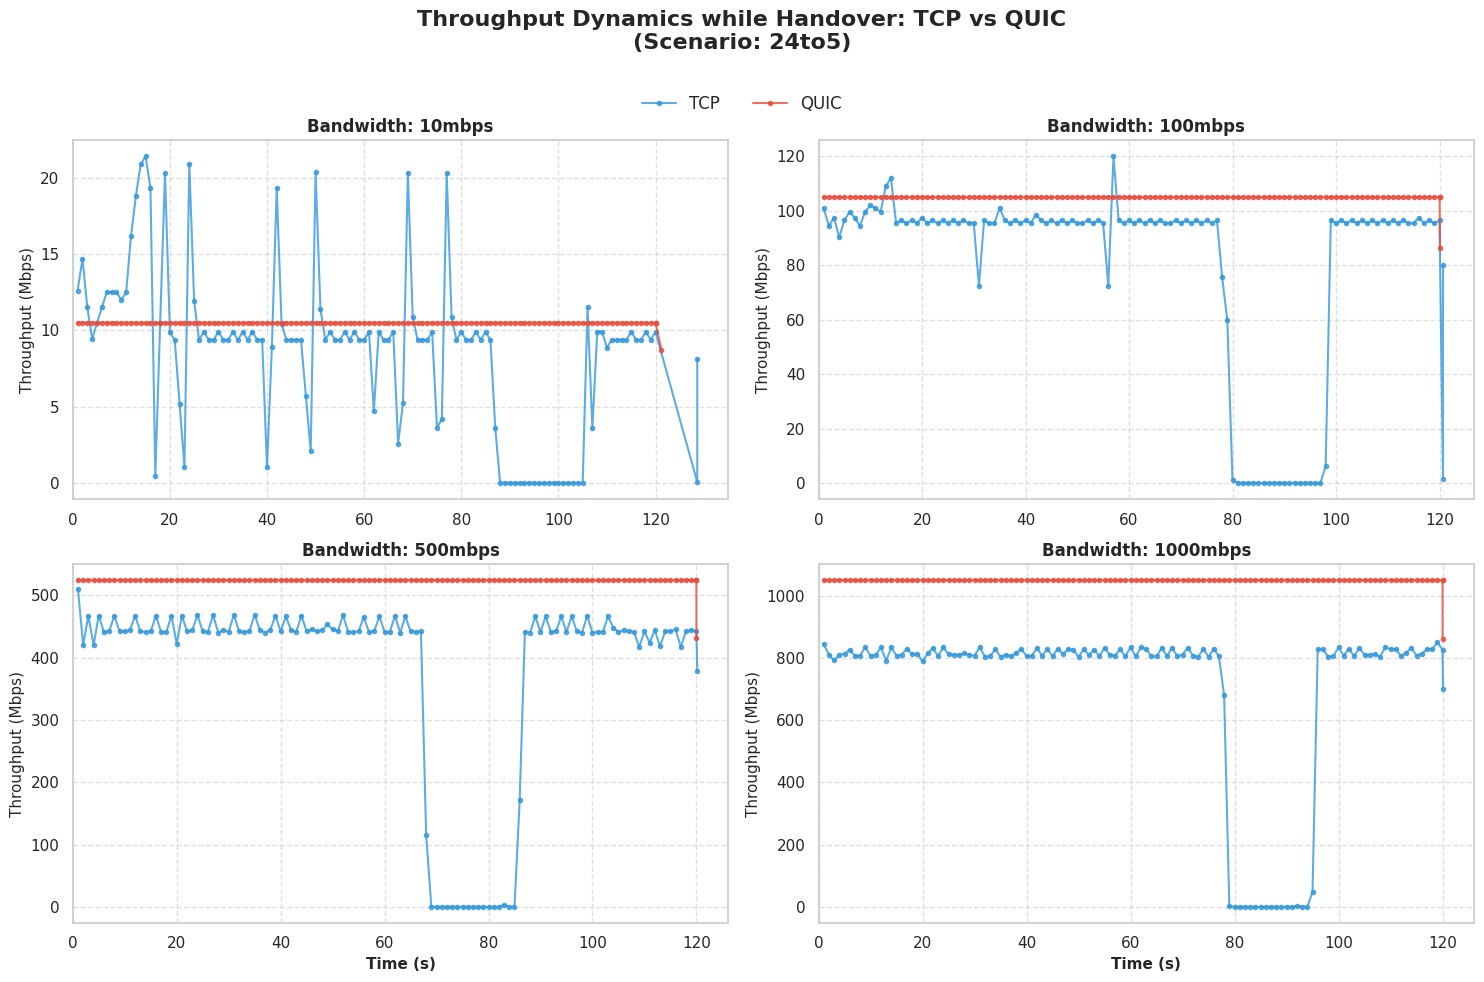


Grafik 4 Grid berhasil dibuat! Silakan simpan gambar ini untuk jurnalmu.


In [ ]:
import os
import re
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- 1. KONFIGURASI TARGET SKENARIO ---
base_path = '/content/drive/MyDrive/parameters'
protocols = ['tcp', 'quic']

# Target diubah ke 24to5 dengan semua bandwidth
scenario_target = '24to5'
bandwidths = ['10mbps', '100mbps', '500mbps', '1000mbps']

# --- 2. FUNGSI PARSING & REGEX ---
iperf_interval_pat = re.compile(r'-\s*([\d\.]+)\s+sec\s+[\d\.]+\s+[KMG]?Bytes\s+([\d\.]+)\s+([KMG]?bits/sec)')

def normalize_mbps(val, unit):
    if unit == 'Gbits/sec': return val * 1000.0
    if unit == 'Mbits/sec': return val
    if unit == 'Kbits/sec': return val / 1000.0
    if unit == 'bits/sec': return val / 1000000.0
    return 0.0

# --- 3. PROSES EKSTRAKSI DATA & PLOTTING 4 GRID ---
print(f"Membuat 4 Grid Grafik Time-Series Throughput untuk Skenario {scenario_target}...")

# Membuat Figure 2x2
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

palette = {"TCP": "#3498db", "QUIC": "#e74c3c"}
handover_start = 83
handover_end = 104

for i, bw in enumerate(bandwidths):
    ax = axes[i]
    data_found = False

    for proto in protocols:
        dir_path = os.path.join(base_path, proto, scenario_target, bw, 'iperf')
        files = glob.glob(os.path.join(dir_path, '*.log'))

        if files:
            file_to_read = files[0]
            times = []
            throughputs = []

            try:
                with open(file_to_read, 'r') as f:
                    for line in f:
                        match = iperf_interval_pat.search(line)
                        if match and "sender" not in line and "receiver" not in line:
                            t_end = float(match.group(1))
                            val = float(match.group(2))
                            unit = match.group(3)

                            tput_mbps = normalize_mbps(val, unit)
                            times.append(t_end)
                            throughputs.append(tput_mbps)
                            data_found = True

            except Exception as e:
                print(f"Gagal membaca {file_to_read}: {e}")

            if times and throughputs:
                sorted_indices = np.argsort(times)
                times = np.array(times)[sorted_indices]
                throughputs = np.array(throughputs)[sorted_indices]

                ax.plot(times, throughputs,
                        label=f'{proto.upper()}',
                        color=palette[proto.upper()],
                        linewidth=1.5,
                        marker='o', markersize=3, alpha=0.8)

    # --- 4. VISUALISASI TIAP GRID ---
    if data_found:
        ax.set_title(f'Bandwidth: {bw}', fontsize=12, fontweight='bold')
        ax.set_ylabel('Throughput (Mbps)', fontsize=11)
        ax.set_xlim(left=0)
        ax.grid(True, linestyle='--', alpha=0.6)

        # Legend (ax.legend) sengaja DIHAPUS dari sini agar dipindah ke atas keseluruhan gambar

    else:
        ax.set_title(f'{bw} (Data Tidak Ditemukan)')

# Label X-axis cukup di baris terbawah
for ax in axes[2:]:
    ax.set_xlabel('Time (s)', fontsize=11, fontweight='bold')

# Judul Utama
fig.suptitle(f'Throughput Dynamics while Handover: TCP vs QUIC\n(Scenario: {scenario_target})',
             fontsize=16, fontweight='bold', y=0.98)

# ==============================================================================
# PERUBAHAN ADA DI SINI: MEMBUAT LEGEND GABUNGAN DI ATAS TENGAH
# ==============================================================================
# Mengambil sampel handle garis dan label dari grid pertama (axes[0])
handles, labels = axes[0].get_legend_handles_labels()

# Meletakkan legend di tengah atas, mendatar (ncol=2)
fig.legend(handles, labels,
           loc='upper center',
           bbox_to_anchor=(0.5, 0.91), # Mengatur posisi koordinat (X=0.5, Y=0.91)
           ncol=2,
           fontsize=12,
           frameon=False) # Hilangkan bingkai legend agar lebih bersih

plt.tight_layout()
# Menurunkan sedikit posisi grafik (top=0.85) agar memberi ruang kosong untuk Legend di atas
fig.subplots_adjust(top=0.85)
plt.show()
print("\nGrafik 4 Grid berhasil dibuat! Silakan simpan gambar ini untuk jurnalmu.")